## Task 2.2 Data Visualisation

<IPython.core.display.Javascript object>


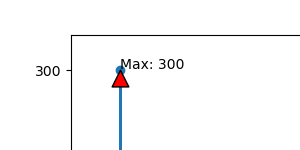

In [ ]:
%matplotlib notebook
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime

host_ip = "172.23.224.1"
client = MongoClient(host_ip, 27017)
db = client.fit3182_db
collection = db.violations

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))
all_data = pd.DataFrame()

while True:
    data = []
    for doc in collection.find():
        for v in doc["all_violations"]:
            ts = pd.to_datetime(v["timestamp"])
            data.append({
                "car_plate": doc["car_plate"],
                "violation_type": v["violation_type"],
                "timestamp": ts,
                "camera_id": v['camera_id'],
                "speed": v['speed']
            })

    if data:
        new_df = pd.DataFrame(data)
        all_data = pd.concat([all_data, new_df], ignore_index=True)
        
        # Plot 1: Violation Count
        violation_count = all_data.groupby("timestamp").size().reset_index(name="count")
        ax1.clear()
        ax1.plot(violation_count["timestamp"], violation_count["count"], marker='o')
        ax1.set_title("Number of Violations vs Time")
        ax1.set_xlabel("Time")
        ax1.set_ylabel("Violations Count")
        ax1.tick_params(axis='x', labelrotation=45)

        max_idx = violation_count['count'].idxmax()
        min_idx = violation_count['count'].idxmin()

        ax1.annotate(f"Max: {violation_count['count'][max_idx]}",
                     (violation_count['timestamp'][max_idx], violation_count['count'][max_idx]),
                     xytext=(violation_count['timestamp'][max_idx], violation_count['count'][max_idx]+0.5), arrowprops=dict(facecolor='red', shrink=0.05))
        ax1.annotate(f"Min: {violation_count['count'][min_idx]}",
                     (violation_count['timestamp'][min_idx], violation_count['count'][min_idx]),
                     xytext=(violation_count['timestamp'][min_idx], violation_count['count'][min_idx]+0.5), arrowprops=dict(facecolor='red', shrink=0.05))
        
        # Plot 2
        ax2.clear()
        ax2.plot(all_data["timestamp"], all_data["speed"], marker='o')
        ax2.set_title("Vehicle Speed vs Time")
        ax2.set_xlabel("Time")
        ax2.set_ylabel("Speed (km/h)")
        ax2.tick_params(axis='x', labelrotation=45)

        max_speed_idx = all_data['speed'].idxmax()
        mean_speed = all_data["speed"].mean()
        ax2.annotate(f"Max: {all_data['speed'][max_speed_idx]}",
                     (all_data['timestamp'][max_speed_idx], all_data['speed'][max_speed_idx]),
                     xytext=(all_data['timestamp'][max_speed_idx], all_data['speed'][max_speed_idx]+0.5), arrowprops=dict(facecolor='red', shrink=0.05))
        ax2.axhline(mean_speed, color='orange', linestyle='--', label=f'Average Speed: {mean_speed:.1f} km/h')
        ax2.legend()

        fig.canvas.draw()
        plt.tight_layout()

    time.sleep(5)

In [1]:
import folium
from pymongo import MongoClient
import pandas as pd
from datetime import datetime, timedelta
from collections import defaultdict

hostip = "172.23.224.1"
violation_threshold = 50

# Connect to MongoDB
client = MongoClient(hostip, 27017)
db = client['fit3182_db']
violations = db['violations']
cameras = db['cameras']

# Let user input date to filter violations
selected_date = input("Enter date (YYYY-MM-DD): ").strip()

# Load camera data and store coordinates
camera_locations = {}
latitudes = []
longitudes = []

for cam in cameras.find():
    camera_id = str(cam["camera_id"])
    lat = float(cam["latitude"])
    lon = float(cam["longitude"])
    
    camera_locations[camera_id] = (lat, lon)
    latitudes.append(lat)
    longitudes.append(lon)
    
# Calculate the average center point of all cameras for initializing map
avg_lat = sum(latitudes) / len(longitudes)
avg_lon = sum(longitudes) / len(longitudes)
map_center = [avg_lat, avg_lon]

# Initialise the Folium map
fomap = folium.Map(location=map_center, zoom_start=15)

# Collect all violations for the selected date
all_violations = []

for v in violations.find():
    car_plate = v["car_plate"]
    for entry in v["all_violations"]:
        ts = entry.get("timestamp")
        if isinstance(ts, str):
            ts_obj = datetime.fromisoformat(ts)
        else:
            ts_obj = ts
        if ts_obj.strftime("%Y-%m-%d") == selected_date:
            all_violations.append({
                "camera_id": entry["camera_id"],
                "speed": entry["speed"],
                "violation_type": entry["violation_type"]
            })
            
# Count violations per camera (instantaneous) and between cameras (average speed)
camera_counts = defaultdict(int)
checkpoint_counts = defaultdict(int)

for v in all_violations:
    cam_id = str(v["camera_id"])
    
    if v["violation_type"] == "instantaneous":
        camera_counts[cam_id] += 1
    
    elif v["violation_type"] == "average_speed":
        end_cam = cam_id
        start_cam = str(int(cam_id) - 1)
        if start_cam in camera_locations and end_cam in camera_locations:
            checkpoint = tuple(sorted([start_cam, end_cam]))
            checkpoint_counts[checkpoint] += 1
            
# Add camera markers with colors based on violation count
for cam_id, (lat, lon) in camera_locations.items():
    count = camera_counts.get(cam_id, 0)
    color = "red" if count > violation_threshold else "blue"
    folium.Marker(
        location=(lat, lon),
        popup=f"Camera {cam_id}:\n{count} instantaneous violations",
        icon=folium.Icon(color=color)
    ).add_to(fomap)
    
# Add lines between camera pairs for average speed violations
for (cam1, cam2), count in checkpoint_counts.items():
    if cam1 in camera_locations and cam2 in camera_locations:
        loc1 = camera_locations[cam1]
        loc2 = camera_locations[cam2]
        color = "red" if count > violation_threshold else "purple"
        folium.PolyLine(
            locations=[loc1, loc2],
            color=color,
            weight=2,
            opacity=0.7,
            popup=f"Camera {cam1} → {cam2}:\n{count} average speed violations"
        ).add_to(fomap)

# Display the map
fomap

Enter date (YYYY-MM-DD): 2024-01-01


## Task 2.2.3 Data Visualisation - Justification

### Violation Count vs Time

##### Caption
Plot showing the number of violation against time.

##### Justification
Plotting the number of violations against arrival time helps to identify temporal patterns in traffic violations. Interesting points such as maximum and minimum violation counts reveal peak hours or quiet periods of noncompliance. These insights are crucial to understand when violations tend to cluster, enabling law enforcement to allocate resources efficiently during high-risk periods.

##### Interesting Points
- Maximum Violations: marks critical times that require urgent attention or enhanced monitoring
- Minumum Violations: indicates effective enforcement or naturally low traffic periods

##### Implications
Understanding violation trends over time supports dynamic enforcement schedules, preventing resource wastage during low-violation periods and focusing efforts during peak violation hours.

### Speed vs Time

##### Caption
Plot showing the speed against time.

##### Justification
Plotting vehicle speeds against arrival time provides insights into speeding behaviors and compliance patterns throughout the day. Labeling interesting points like the average speed and maximum speed offers a summary of typical and extreme driver behavior, which can indicate risk levels on the roads.

##### Interesting Points
- Average Speed: shows overall traffic flow and compliance levels, helping to evaluate if speed limits are reasonable or frequently violated
- Maximum Speed: signals potentially dangerous behavior that might warrant immediate intervention

##### Implications
Speed trend analysis aids in adjusting speed limits, designing traffic calming measures, and prioritizing enforcement actions during periods when dangerous speeding is most frequent.

### Violation Map

##### Map Description
This interactive map visualizes traffic speed violations detected across three cameras on a selected date. It uses camera locations to spatially represent violation data, with annotations indicating the number of violations between checkpoints.

##### Hotspot
A hotspot is defined here as any location (camera or checkpoint pair) where the number of violations exceeds the threshold of 50 in a single day. This threshold was selected to highlight abnormal congestion or noncompliance, helping prioritize limited enforcement resources.

##### Interesting Points
Highlighting hotspots enables quick identification of high-risk locations, which is critical for focusing limited resources effectively. Annotating violation counts on the map also provides clear spatial context to the temporal data seen in other plots.

##### Implications
In the folium map, red camera markers signal areas for targeted enforcement or infrastructure review, such as adjusting speed limits or installing physical deterrents. Besides, red checkpoint lines indicate problematic road segments where interventions like road redesign or camera recalibration may be necessary.

### Why interesting points are important

Interesting points are essential in traffic data visualizations because they distill complex information into easily interpretable insights. By highlighting values such as maximum violations, minimum speeds, and hotspots, stakeholders can quickly identify when and where issues occur without scanning the entire dataset. This enhances situational awareness and supports more focused decision-making.

These key data points also guide operational efficiency. For example, knowing peak violation times or locations allows law enforcement to allocate personnel and resources dynamically, improving coverage during high-risk periods while avoiding waste during quiet hours. Similarly, identifying excessive speeds can prompt immediate safety interventions.

Lastly, emphasizing interesting points makes visualizations more impactful and actionable, especially for non-technical audiences. They help communicate urgency, justify policy changes, and support long-term planning—such as adjusting speed limits, redesigning roads, or deploying automated alerts for recurring patterns—thereby turning raw data into practical strategies for enhancing road safety.

### Proposed Future Work

Enhance the map with interactive features, such as adjustable thresholds and zoom-based clustering, for better usability.